In [1]:
!pip install datasets==2.18.0 pyarrow==15.0.0 kagglehub


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [4]:
import kagglehub
import pandas as pd
import numpy as np
from datasets import load_dataset
from pathlib import Path

/root/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Import Datasets

https://huggingface\.co/datasets/Rajarshi\-Roy\-research/Defactify\_Image\_Dataset

https://www\.kaggle\.com/datasets/birdy654/cifake\-real\-and\-ai\-generated\-synthetic\-images/data

https://www\.kaggle\.com/datasets/birdy654/cifake\-real\-and\-ai\-generated\-synthetic\-images/data

https://ieee\-dataport\.org/documents/deepguarddb\-real\-and\-text\-image\-synthetic\-images\-dataset

In [7]:
def get_kaggle_df(kaggle_birdy=False):
    """
    Returns a dataframe with rows "image", "fake", and "year"
    # TODO: read in files as images, then convert images to tensors
    """
    if not kaggle_birdy:
        return None # not expecting other kaggle datasets yet. If there are, change path
    path = kagglehub.dataset_download("birdy654/cifake-real-and-ai-generated-synthetic-images")
    labels = []
    file_names = []
    for file in sorted((Path(path).glob('*/*/*.*'))):
        label = str(file).split('/')[-2]
        labels.append(True if label == "FAKE" else False)
        file_names.append(str(file))
    df = pd.DataFrame({"image":file_names, "fake":labels})
    return df

def get_hugging_face_df(rajarshi=True):
    """Returns a dataframe with rows 'file', 'label', and 'year'"""
    if not rajarshi:
        hug_train_data = load_dataset(path="Rajarshi-Roy-research/Defactify_Image_Dataset",split="train[:1%]")
        hug_train_df = pd.DataFrame(hug_train_data) # from huggingface dataset info of data last_modified and data last_created
        hug_train_df = hug_train_df[["Image", "Label_A"]].rename(columns={'Label_A': 'fake'})
        hug_train_df["fake"] = hug_train_df["fake"].astype(bool)
        return hug_train_df
    else:
        hug_train_data = load_dataset(path="Hemg/AI-Generated-vs-Real-Images-Datasets",split="train[:1%]")
        hug_train_df = pd.DataFrame(hug_train_data)
        hug_train_df = hug_train_df[["image", "label"]].rename(columns={'label': 'fake'})
        hug_train_df["fake"] = hug_train_df["fake"].astype(bool)
        return hug_train_df

In [13]:
dataset_links = {
    "kaggle_birdy654": "https://www.kaggle.com/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images/data?select=test",
    "huggingface_rajarshi":"https://huggingface.co/datasets/Rajarshi-Roy-research/Defactify_Image_Dataset",
    "huggingface_hemg":"https://huggingface.co/datasets/Hemg/AI-Generated-vs-Real-Images-Datasets",
    "ieee_deepguard":"https://ieee-dataport.org/documents/deepguarddb-real-and-text-image-synthetic-images-dataset",
}

datasets_to_dfs = {
    "kaggle_birdy654": get_kaggle_df(kaggle_birdy=True),
    "huggingface_rajarshi": get_hugging_face_df(rajarshi=True),
    "huggingface_hemg": get_hugging_face_df(rajarshi=False),
    "ieee_deepguard": ...,
}

dataset_years = {
    "kaggle_birdy654": 2023,  # based on basic online search (could be wrong. Likely 2022-2023)
    "huggingface_rajarshi": 2025,
    "huggingface_hemg": 2024,  # based on commit history (could be wrong)
    "ieee_deepguard": ...,
}

REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL
REAL


Separating kaggle data into X\_train, X\_test, Y\_train, Y\_test

In [24]:
get_df(path).head()

,file,label
0,/root/.cache/kagglehub/datasets/birdy654/cifak...,FAKE
1,/root/.cache/kagglehub/datasets/birdy654/cifak...,FAKE
2,/root/.cache/kagglehub/datasets/birdy654/cifak...,FAKE
3,/root/.cache/kagglehub/datasets/birdy654/cifak...,FAKE
4,/root/.cache/kagglehub/datasets/birdy654/cifak...,FAKE


# Importing hugging face AI generated data set

In [13]:
# Takes about 5 min to load and generate train, validation, test splits
from datasets import load_dataset
hug_train_data = load_dataset(path="Rajarshi-Roy-research/Defactify_Image_Dataset",split="train[:1%]")

/root/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Generating test split: 100%|██████████| 45000/45000 [00:13<00:00, 3424.26 examples/s]


Index(['Image', 'fake'], dtype='object')


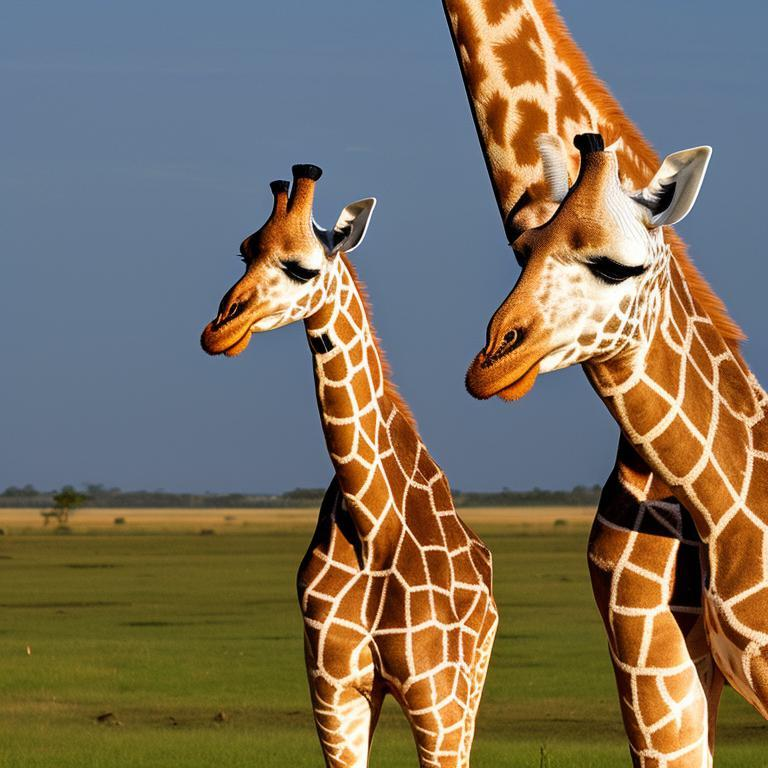

In [ ]:
# hug_train_df = pd.DataFrame(hug_train_data) # from huggingface dataset info of data last_modified and data last_created
# hug_train_df = hug_train_df[["Image", "Label_A"]].rename(columns={'Label_A': 'fake'}) # match Ravi's df
hug_train_df = datasets_to_dfs["huggingface_rajarshi"]
print(hug_train_df.columns)
hug_train_df["Image"][1]

Got real images \> Described with caption \> Fed it to LLMs to generate AI pictures

In [23]:
from huggingface_hub import dataset_info

info = dataset_info("Rajarshi-Roy-research/Defactify_Image_Dataset")
print(info.created_at)
print(info.last_modified)

2025-11-29 06:23:32+00:00
2025-11-29 07:02:46+00:00


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=ca50555b-201c-448d-974c-16107e326479' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>